In [1]:
import sys
sys.path.append('../code')
import jax
from jax import jit, vmap
import jax.numpy as jnp
import jaxley as jx
from jaxley.channels import Na, K, Leak, Km, CaL, CaT
from jaxley.synapses import IonotropicSynapse

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (set_train_parameters, simulate, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, initialize_params, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
import intrinsic_prior_configurations as prior_config


config.update("jax_enable_x64", True)
# config.update("jax_platform_name", "cpu")
config.update("jax_platform_name", "gpu")

In [2]:
save_path = '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations'

config_list = [
    ('Esoma_Isoma', prior_config.update_prior_dict_Esoma_Isoma), # 0
    ('Edend_Idend', prior_config.update_prior_dict_Edend_Idend), # 1
    ('Esoma_Idend', prior_config.update_prior_dict_Esoma_Idend), # 2
    ('Edend_Isoma', prior_config.update_prior_dict_Edend_Isoma), # 3
    ('Esoma_Isomadend', prior_config.update_prior_dict_Esoma_Isomadend), # 4
    ('Edend_Isomadend', prior_config.update_prior_dict_Edend_Isomadend), # 5
    # ('Esomadend_Isoma', prior_config.update_prior_dict_Esomadend_Isoma), # 6
    # ('Esomadend_Idend', prior_config.update_prior_dict_Esomadend_Idend), # 7
    # ('Esomadend_Isomadend', prior_config.update_prior_dict_Esomadend_Isomadend) # 8
    ]

def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 5
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort, 
                }

    return res_dict



In [95]:
def simulate_sweep(theta, params, soma_amp, dend_amp):
    seed_key = jax.random.split(jax.random.PRNGKey(123), num=2)
    key_order = ["cue_ampa_gS", "context_ampa_gS",
                 "IE_gaba_gS", "II_gaba_gS", "EI_ampa_gS", "EE_ampa_gS",
                 "cue_dend_ampa_gS", "context_dend_ampa_gS",
                 "IE_dend_gaba_gS", "EE_dend_ampa_gS",
                 "cue_ampa_pconn", "context_ampa_pconn",
                 "IE_gaba_pconn", "II_gaba_pconn", "EI_ampa_pconn", "EE_ampa_pconn",
                 "cue_dend_ampa_pconn", "context_dend_ampa_pconn",
                 "IE_dend_gaba_pconn", "EE_dend_ampa_pconn",
                 "E_Leak_gLeak", "E_dend_Leak_gLeak", "I_Leak_gLeak",
                 "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT", "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT",
                 "E_dend_Km_gKm", "E_dend_CaL_gCaL", "E_dend_CaT_gCaT",]

    # params is a list of single element dicitonaries, this is to just find the index
    key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
    theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
        theta[param_idx], prior_dict[param_name]['bounds']) for 
        param_idx, param_name in enumerate(key_order)}

    # Need to treat connections with special care
    # First create vector with identicial conductances for every synapse
    # Then mask out connections based on their probability
    for conn_name in ["cue_ampa", "context_ampa", "cue_dend_ampa", "context_dend_ampa",
                      "IE_gaba", "II_gaba", "EI_ampa", "EE_ampa", "IE_dend_gaba", "EE_dend_ampa"]:
        conn_g_name = f'{conn_name}_gS'
        conn_prob_name = f'{conn_name}_pconn'
        key_idx = key_mapping[conn_g_name]
        num_vals = len(params[key_idx][conn_g_name])

        new_vals = np.repeat(theta_dict[conn_g_name], num_vals)
        mask = np.random.uniform(0, 1, size=num_vals) < theta_dict[conn_prob_name]
        new_vals = new_vals * mask

        params[key_idx][conn_g_name] = new_vals

    # No prob masking for biophysics, just update param vectors
    for param_name in ["E_Leak_gLeak", "E_dend_Leak_gLeak", "I_Leak_gLeak",
                       "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT",
                       "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT",
                       "E_dend_Km_gKm", "E_dend_CaL_gCaL", "E_dend_CaT_gCaT",]:
        key_idx = key_mapping[param_name]
        num_vals = len(params[key_idx][param_name])

        new_vals = np.repeat(theta_dict[param_name], num_vals)
        params[key_idx][param_name] = new_vals


    net.delete_stimuli()
    
    # noise_scale = 0.06
    # cue_noise = jax.random.normal(key=seed_key[0], shape=cue_currents.shape) * noise_scale
    # context_noise = jax.random.normal(key=seed_key[1], shape=context_currents.shape) * noise_scale
    
    # data_stimuli = net.cell(list(gid_ranges['cue'])).branch(0).comp(0).data_stimulate(cue_currents + cue_noise)
    # data_stimuli = net.cell(list(gid_ranges['context'])).branch(0).comp(0).data_stimulate(
    #     context_currents + context_noise, data_stimuli=data_stimuli)

    net.delete_recordings()

    soma_currents = jx.datapoint_to_step_currents(i_delay=0.0, i_dur=t_max, i_amp=[soma_amp], delta_t=dt, t_max=t_max)
    dend_currents = jx.datapoint_to_step_currents(i_delay=0.0, i_dur=t_max, i_amp=[dend_amp], delta_t=dt, t_max=t_max)

    soma_noise = jnp.abs(jax.random.normal(key=seed_key[0], shape=soma_currents.shape) * soma_amp)
    dend_noise = jnp.abs(jax.random.normal(key=seed_key[1], shape=dend_currents.shape) * dend_amp)


    # data_stimuli = net.cell(list(gid_ranges['E'])[0]).branch(0).comp(0).data_stimulate(soma_currents)
    # data_stimuli = net.cell(list(gid_ranges['E'])[0]).branch(3).comp(3).data_stimulate(dend_currents, data_stimuli=data_stimuli)

    data_stimuli = net.cell(list(gid_ranges['E'])[0]).branch(0).comp(0).data_stimulate(soma_noise)
    data_stimuli = net.cell(list(gid_ranges['E'])[0]).branch(3).comp(3).data_stimulate(dend_noise, data_stimuli=data_stimuli)
    
    # net.branch(0).comp(0).record('v')
    net.cell(list(gid_ranges['E'])[0]).branch(0).comp(0).record('v')

    s = jx.integrate(net, t_max=t_max, params=params, checkpoint_lengths=checkpoints, data_stimuli=data_stimuli)
    
    return s

In [96]:
flow_idx = 4 # flow used for random init simulations

dt = 0.025
t_max = 500
time_vec = jnp.arange(0, t_max, dt)

downsample_factor = 10
dt_flow = dt * downsample_factor
fs_flow = (1/dt_flow) * 1e3
time_vec_flow = np.arange(0, t_max, dt_flow)
burn_in = int(8000 / downsample_factor)

# Used to reduce GPU memory (passed to simulate function)
levels = 2
time_points = t_max // dt + 2
checkpoints = [int(np.ceil(time_points**(1/levels))) for _ in range(levels)]

for config_name, update_prior_dict in config_list[5:6]:
    print(config_name)
    data_path = f'{save_path}/{config_name}'

    with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
        net, gid_ranges = pickle.load(f)

    res_dict = get_opt_data(data_path)
    theta = res_dict['theta_list'][flow_idx]
    theta_idx = np.argmin(res_dict['error_list'][flow_idx])

    num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
    num_cue_cells = len(gid_ranges['cue'])

    params, _ = set_train_parameters(net, gid_ranges)
    prior_dict = get_prior_dict()
    update_prior_dict(prior_dict)

    # Set all synaptic conductances to zero
    for param_name in prior_dict.keys():
        if 'gS' in param_name:
            print(param_name, end=' ')
            prior_dict[param_name]['bounds'] = (-20, -20)
        if 'pconn' in param_name:
            print(param_name, end=' ')
            prior_dict[param_name]['bounds'] = (0, 0)


            

    

Edend_Isomadend
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Edend_Isomadend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 942. Total number of trainable parameters: 942


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 478. Total number of trainable parameters: 1420


...

/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 10527


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 10577
Number of newly added trainable parameters: 50. Total number of trainable parameters: 10627
cue_ampa_gS context_ampa_gS IE_gaba_gS II_gaba_gS EI_ampa_gS EE_ampa_gS cue_dend_ampa_gS context_dend_ampa_gS IE_dend_gaba_gS EE_dend_ampa_gS cue_ampa_pconn context_ampa_pconn IE_gaba_pconn II_gaba_pconn EI_ampa_pconn EE_ampa_pconn cue_dend_ampa_pconn context_dend_ampa_pconn IE_dend_gaba_pconn EE_dend_ampa_pconn 

/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


In [97]:
sweep_size = 30
soma_amp_list, dend_amp_list = list(), list()
for amp1 in np.linspace(0, 2, sweep_size):
    for amp2 in np.linspace(0, 2, sweep_size):
        soma_amp_list.append(amp1)
        dend_amp_list.append(amp2)

soma_amp_array = jnp.array(soma_amp_list)
dend_amp_array = jnp.array(dend_amp_list)

num_simulations = len(soma_amp_array)

In [98]:
jitted_simulate = jit(simulate_sweep)
jitted_vmapped_simulate = vmap(jitted_simulate, in_axes=(None, None, 0, 0))

batch_size = 20

output_list = list()
for start_idx in range(0, num_simulations, batch_size):
    print(f'Batch: {start_idx}')
    end_idx = np.min([start_idx + batch_size, num_simulations])

    soma_amp = soma_amp_array[start_idx:end_idx]
    dend_amp = dend_amp_array[start_idx:end_idx]

    output = np.array(jitted_vmapped_simulate(theta[theta_idx, :], params, soma_amp, dend_amp))
    output_list.append(output)

output_array = np.concatenate(output_list).squeeze()

Batch: 0
Added 1 recordings. See `.recordings` for details.
Batch: 20
Batch: 40
Batch: 60
Batch: 80
Batch: 100
Batch: 120
Batch: 140
Batch: 160
Batch: 180
Batch: 200
Batch: 220
Batch: 240
Batch: 260
Batch: 280
Batch: 300
Batch: 320
Batch: 340
Batch: 360
Batch: 380
Batch: 400
Batch: 420
Batch: 440
Batch: 460
Batch: 480
Batch: 500
Batch: 520
Batch: 540
Batch: 560
Batch: 580
Batch: 600
Batch: 620
Batch: 640
Batch: 660
Batch: 680
Batch: 700
Batch: 720
Batch: 740
Batch: 760
Batch: 780
Batch: 800
Batch: 820
Batch: 840
Batch: 860
Batch: 880


In [93]:
threshold = 0
spike_counts = list()
for sim_idx in range(output_array.shape[0]):
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_times = np.where(np.diff(above_threshold.astype(int)) == 1)[0]
    spike_counts.append(len(spike_times))
spike_counts = np.array(spike_counts)

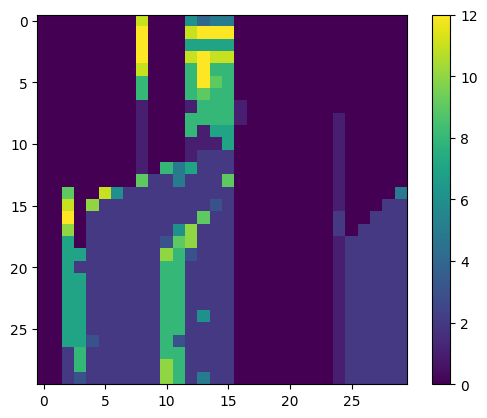

In [94]:
plt.imshow(spike_counts.reshape(sweep_size, sweep_size))
plt.colorbar()

Text(0, 0.5, 'Depth')

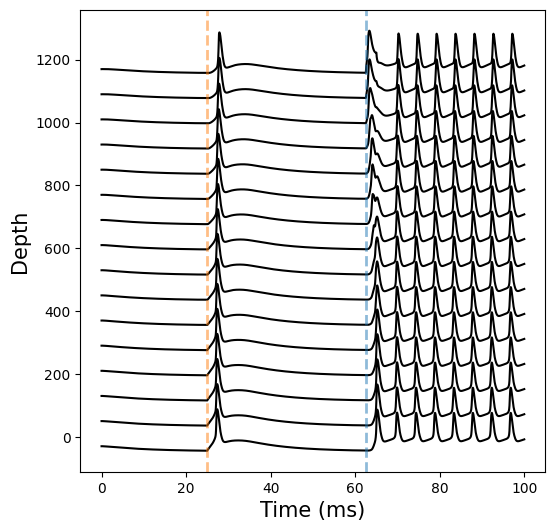

In [55]:
plt.figure(figsize=(6,6))
plt.plot(time_vec, s[0:16,:-1].T + np.arange(16) * 80 + 40, color='k')
plt.axvline(time_vec[soma_start], color='C1', linewidth=2, linestyle='--', alpha=0.5)
plt.axvline(time_vec[dend_start], color='C0', linewidth=2, linestyle='--', alpha=0.5)
plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('Depth', fontsize=15)